<a href="https://colab.research.google.com/github/rashydaii/ballon-d-or-prediction-/blob/main/Rashik_Week5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
df = pd.read_csv("/content/IMDB-Dataset.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset Shape:
(50000, 2)


In [11]:
print(df.shape)
print(df['sentiment'].value_counts())

(28506, 2)
sentiment
positive    14266
negative    14240
Name: count, dtype: int64


In [21]:
df['sentiment'] = df['sentiment'].map({
    'negative':0,
    'positive':1
})

print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


In [22]:
#tokenize text
max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(df['review'])

X = tokenizer.texts_to_sequences(df['review'])

In [29]:
#pad sequences
max_len = 200

X = pad_sequences(X,
                  maxlen=max_len)

y = df['sentiment'].values

In [24]:
#train test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (40000, 200)
Testing Shape: (10000, 200)


In [45]:
max_words = 10000
max_len = 200

# Build model
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=max_words, output_dim=128),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 250ms/step - accuracy: 0.7996 - loss: 0.4245 - val_accuracy: 0.8794 - val_loss: 0.2883
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 275ms/step - accuracy: 0.9068 - loss: 0.2423 - val_accuracy: 0.8766 - val_loss: 0.2937
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 254ms/step - accuracy: 0.9299 - loss: 0.1926 - val_accuracy: 0.8763 - val_loss: 0.3020
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.9415 - loss: 0.1558 - val_accuracy: 0.8741 - val_loss: 0.3148
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 62s 247ms/step - accuracy: 0.9518 - loss: 0.1315 - val_accuracy: 0.8715 - val_loss: 0.3664


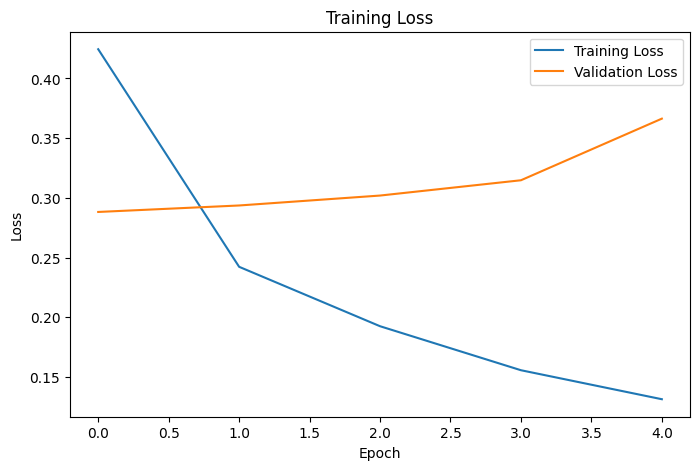

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()

plt.show()

In [42]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8724 - loss: 0.3481
Test Accuracy: 0.8723999857902527


In [43]:
pred = model.predict(X_test)

pred = (pred>0.5).astype(int)

print(pred[:10].flatten())

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
[0 1 0 1 0 1 1 0 1 0]


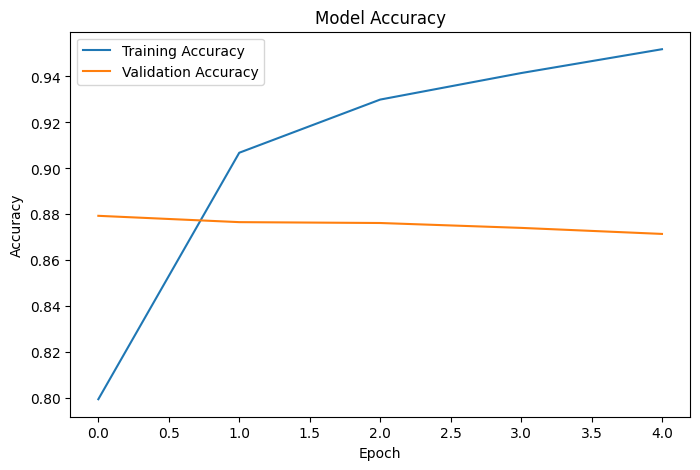

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()

plt.show()